# k-Nearest Neighbors

In this lab you will explore tuning a k-Nearest Neighbors model for image classification.

We will use the [Fashion MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) provided by the [Keras library](https://keras.io/api/datasets/fashion_mnist/).  You will need to install Keras and PyTorch to access the dataset.

In [7]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 17.5 MB/s eta 0:02:20
     ---------------------------------------- 0.0/2.4 GB 22.7 MB/s eta 0:01:48
     ---------------------------------------- 0.0/2.4 GB 32.3 MB/s eta 0:01:16
     ---------------------------------------- 0.0/2.4 GB 32.8 MB/s eta 0:01:15
     ---------------------------------------- 0.0/2.4 GB 35.6 MB/s eta 0:01:09
     ---------------------------------------- 0.0/2.4 GB 35.1 MB/s eta 0:01:10
     ---------------------------------------- 0.0/2.4 GB 36.7 MB/s eta 0:01:07
     ---------------------------------------- 0.0/2.4 GB 40.9 MB/s eta 0:01:00
     ---------------------------------------- 0.0/2.4 GB 38.5 MB/s eta 0:01:04
     ---------------------------------------- 0.0/2.4 GB 38.5 MB/s eta 0:01:04
     ---------------------------------------- 0.0/2.4 GB 38.5 MB/s eta 0:01:04
 

In [1]:
import glob
import imageio
import skimage
from matplotlib import pyplot as plt
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog

import os
os.environ['KERAS_BACKEND'] = 'torch'
from keras.datasets import fashion_mnist

Here we load the dataset and show some example images.  Each class is a different category of clothing like shoe, t-shirt, or dress.  The classes are mostly distinguishable by shape, and so they are a good candidate for classification using the [HOG (Histogram of Gradients)](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_hog.html) descriptor which captures shape well.

In [2]:
(train_images,train_labels),(val_images,val_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


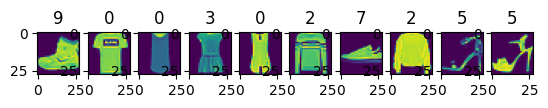

In [3]:
fig,axes = plt.subplots(1,10)
for i,ax in enumerate(axes):
    axes[i].imshow(train_images[i])
    axes[i].set_title(train_labels[i])

Now what we have are lists `train_images` and `train_labels` containing the images and labels for the training set, and the same for the validation set.

1. Compute a HOG descriptor for each image to make two lists, `train_descriptors` and `val_descriptors` (```skimage.feature.hog```).

In [7]:
train_descriptors = [hog(img) for img in train_images]
val_descriptors = [hog(img) for img in val_images]

2. Build a k-nearest neighbors classifier on the training set (```sklearn.neighbors.KNeighborsClassifier```).

This model will find the $k$ nearest neighbors to the query point and output the most common label.  Use the default value of $k$.

Run the model on the test set and print out the accuracy (```sklearn.metrics.accuracy_score``` or simply use ```model.score```).

In [9]:
def build(k=5):
    knn = KNeighborsClassifier(k)
    knn.fit(train_descriptors, train_labels)
    return knn

knn = build()
knn.score(val_descriptors, val_labels)

0.8295

3. Test $k$ from 1 to 101 in increments of 10 and make a plot of the train and test accuracy versus $k$.  Analyze the trade-off between over- and underfitting changes as $k$ increases.  Which is the best setting of $k$?

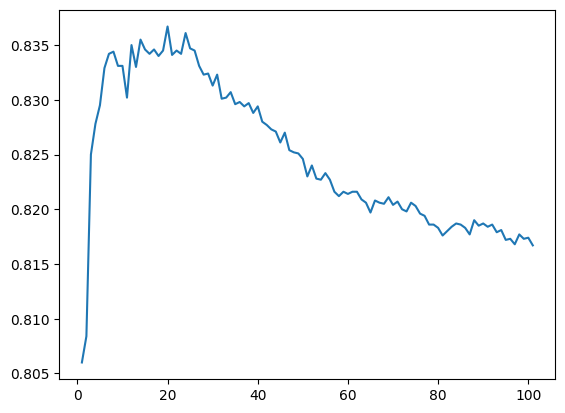

In [10]:
accuracies = []
for i in range(1, 102):
    knn = build(i)
    accuracies.append(knn.score(val_descriptors, val_labels))

plt.plot(range(1, 102), accuracies)
plt.show()

It looks like the best values of k lie around 25-30, but is relatively the same from 15->30. After 35, it seems that performance does tend to drop of significantly.